In [10]:
#Task 1: Data feature engineering
import pandas as pd

df=pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#Extracting date components
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))




  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0


In [11]:
#Task 2: Temporal Train-test split
df = df.sort_values('transaction_date').reset_index(drop=True)

cutoff = int(len(df) * 0.8)

train = df.iloc[:cutoff] #first 80% of data
test = df.iloc[cutoff:] #last 20% of data
print(f"Train Size: {len(train)} | Date range: {train['transaction_date'].min()} to {train['transaction_date'].max()}")
print(f"Test size: {len(test)} | Date range: {test['transaction_date'].min()} to {test['transaction_date'].max()}")

Train Size: 960 | Date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test size: 240 | Date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


Random split would be wrong for time-rdered data as it lets future data leak into the training set as well as past data into a test set thus reducing the accuracy of such tests by making them too optimistic which becomes misleading. To avoid such biases, we always train on past records and test on newer ones. 

In [12]:
#Task 3: Preprocessing pipeline
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Defining which coloumns get what treatment
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [
    'year', 'month', 'day_of_week', 'is_month_end', #Features engineered from dataset
    'is_weekend', 'is_festival', 'competition_density'
]
cat_transformer = OneHotEncoder(drop ='first', sparse_output=False) #Avoiding the dummy variable trap.
num_transformer = StandardScaler() 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ], remainder='drop')

#preparing X and y 
feature_cols = categorical_cols + numerical_cols
X_train = train[feature_cols]
y_train = train['items_sold']

X_test = test[feature_cols]
y_test = test['items_sold']

#Verifying sanity of the pipeline
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")




X_train shape: (960, 10) | X_test shape: (240, 10)



 Linear Regression
 RMSE : 27.13
 MAE : 21.07


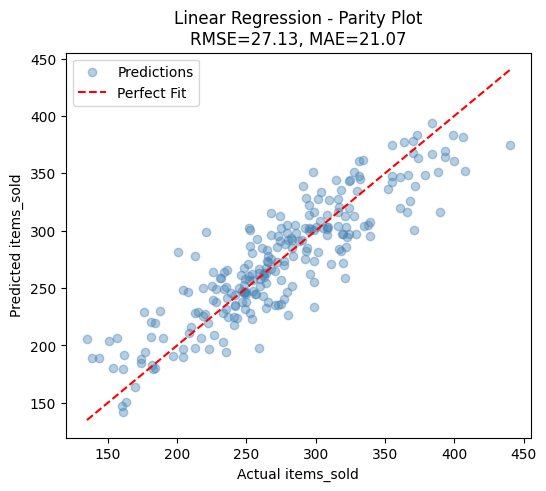


 Random Forest 
 RMSE : 31.96
 MAE : 25.65


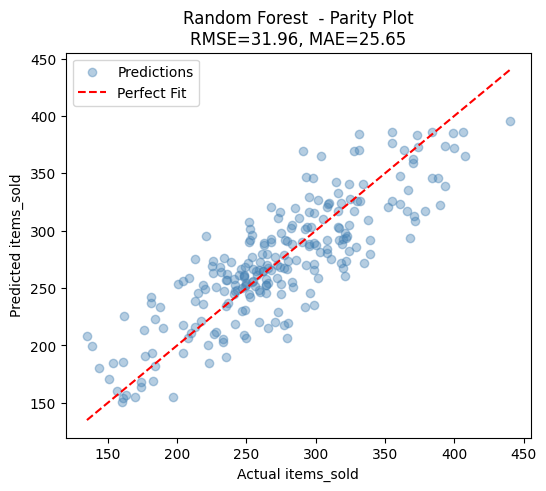


Top 5 most influential features (Random Forest):
                 feature  importance
     competition_density    0.184408
     location_type_urban    0.174561
              is_weekend    0.141088
promotion_type_free_gift    0.106424
       store_size_medium    0.067384


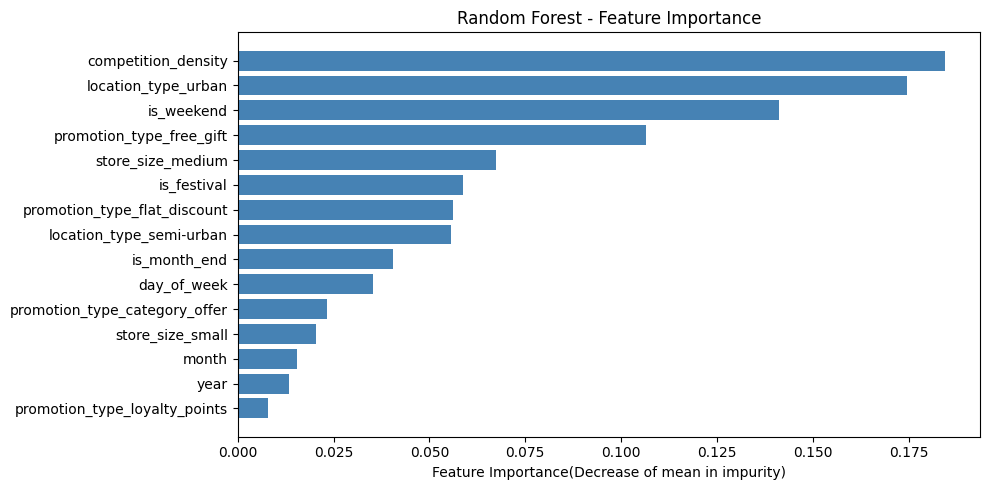

In [13]:
#Task 4: Model training and evaluation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(name, model, preprocessor, X_train, y_train, X_test, y_test):
    #Wrapping preprocessor and model in a pipeline
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    #Fitting the model ONLY on training data
    pipe.fit(X_train, y_train)

    #Prediction on test set
    y_pred = pipe.predict(X_test)

    #RMSE: Penalises large errors heavily than MAE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    #MAE: Easier to interpret in original units of the target variable
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f" {name}")
    print(f" RMSE : {rmse:.2f}")
    print(f" MAE : {mae:.2f}")
    print(f"{'='*40}")

    #Parity plot(predicted vs actual)
    fig, ax = plt.subplots(figsize=(6,5))
    ax.scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Predictions')
    #Diagonal line for perfect predictions
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.set_title(f'{name} - Parity Plot\nRMSE={rmse:.2f}, MAE={mae:.2f}')
    ax.legend()
    plt.show()

    return pipe

#Training Linear Regression
lr_pipe = evaluate_model(
    name = "Linear Regression",
    model = LinearRegression(),
    preprocessor = preprocessor ,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test
)
#Training Random Forest 
rf_pipe = evaluate_model(
    name = "Random Forest ", 
    model = RandomForestRegressor(n_estimators=100, random_state=42),
    preprocessor = preprocessor,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test    
)

#Feature importance from Random Forest
fitted_preprocessor = rf_pipe.named_steps['preprocess']

#Getting OHE feature names
ohe_feature_names = (
    fitted_preprocessor
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
    .tolist()
)

#All feature names in the order preprocessor puts them
all_feature_names = ohe_feature_names + numerical_cols
#Extracting importances from trained Random Forest model
importances = rf_pipe.named_steps['model'].feature_importances_

#Dataframe in descending
importance_df = (
    pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print("\nTop 5 most influential features (Random Forest):")
print(importance_df.head(5).to_string(index=False))
#Bar chart of feature importances
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color = 'steelblue')
ax.set_xlabel('Feature Importance(Decrease of mean in impurity)')
ax.set_title('Random Forest - Feature Importance')
plt.tight_layout()
plt.show()

